names of columns in dataset: ['Unnamed: 0', 'content', 'image', 'label']
Number Of Samples : 10010


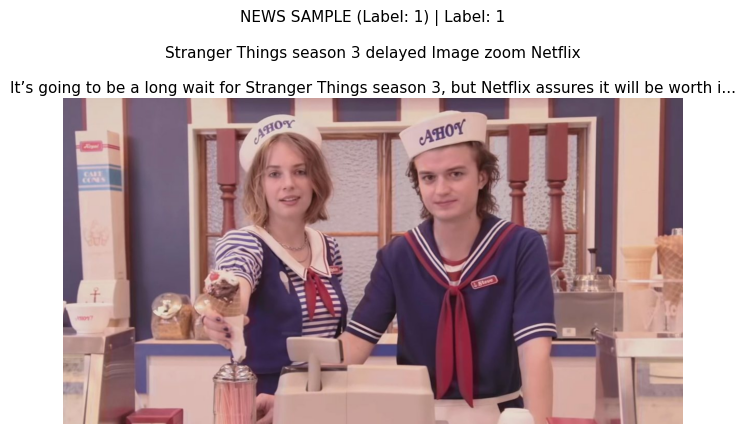

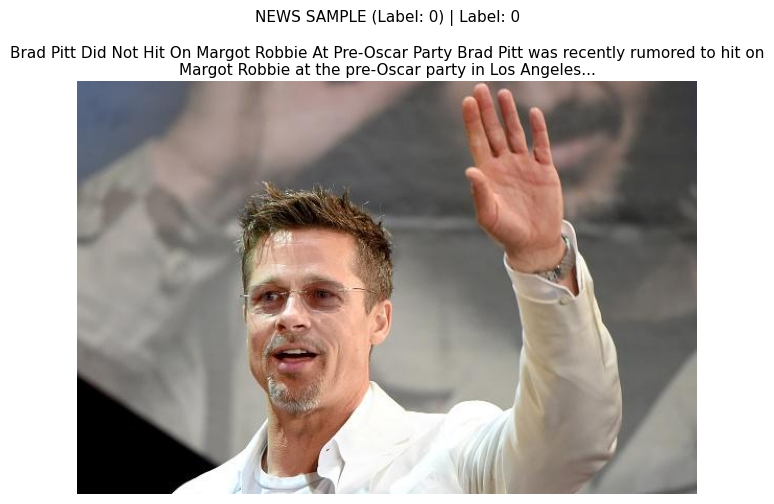

In [ ]:
#cell1
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import os

base_dir = '/kaggle/input/datasets/saikarthikthota/multimodal-fusion-based-fake-news-detection/AAAI_dataset'
csv_path = os.path.join(base_dir, 'gossip_train.csv')
images_dir = os.path.join(base_dir, 'Images', 'gossip_train')

df = pd.read_csv(csv_path)

print("names of columns in dataset:", df.columns.tolist())
print(f"Number Of Samples : {len(df)}")

def plot_multimodal_sample(sample, title_prefix):
    text_col = 'text' if 'text' in df.columns else 'title' if 'title' in df.columns else df.columns[1]
    img_col = 'image' if 'image' in df.columns else 'image_id' if 'image_id' in df.columns else 'id' if 'id' in df.columns else df.columns[0]
    label_col = 'label' if 'label' in df.columns else df.columns[-1]
    
    text = str(sample[text_col].values[0])
    img_name = str(sample[img_col].values[0])
    label = sample[label_col].values[0]
    
    if not img_name.endswith(('.jpg', '.png', '.jpeg')):
        img_name = img_name + '.jpg'
        
    img_path = os.path.join(images_dir, img_name)
    
    image = cv2.imread(img_path)
    
    if image is not None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.axis('off')
        
        wrapped_text = text[:150] + "..." if len(text) > 150 else text
        plt.title(f"{title_prefix} | Label: {label}\n\n{wrapped_text}", fontsize=11, wrap=True)
        plt.show()
    else:
        print(f"Image not found: {img_path}")


labels = df[df.columns[-1]].unique()

try:
    sample_1 = df[df[df.columns[-1]] == labels[0]].sample(1)
    plot_multimodal_sample(sample_1, f"NEWS SAMPLE (Label: {labels[0]})")
    
    if len(labels) > 1:
        sample_2 = df[df[df.columns[-1]] == labels[1]].sample(1)
        plot_multimodal_sample(sample_2, f"NEWS SAMPLE (Label: {labels[1]})")
except Exception as e:
    print("Error:", e)

In [2]:
%pip install -q -U bitsandbytes>=0.46.1 accelerate transformers

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
os._exit(00)

In [1]:
import bitsandbytes as bnb
print("✅ BitsAndBytes version:", bnb.__version__)

✅ BitsAndBytes version: 0.49.2


In [2]:
import pandas as pd
import os
import numpy as np
from torch.utils.data import Dataset
from PIL import Image

BASE_PATH = '/kaggle/input/datasets/saikarthikthota/multimodal-fusion-based-fake-news-detection/AAAI_dataset'
CSV_PATH = os.path.join(BASE_PATH, 'gossip_train.csv')
IMAGES_DIR = os.path.join(BASE_PATH, 'Images', 'gossip_train')

def load_and_balance_data():
    if not os.path.exists(CSV_PATH):
        print(f"Error: CSV not found at {CSV_PATH}")
        return []
    
    df = pd.read_csv(CSV_PATH)
    
    df_real = df[df['label'] == 1]
    df_fake = df[df['label'] == 0]
    
    print(f"Original Data -> Real: {len(df_real)}, Fake: {len(df_fake)}")
    
    min_count = min(len(df_real), len(df_fake))
    
    df_real_balanced = df_real.sample(min_count, random_state=42)
    df_fake_balanced = df_fake.sample(min_count, random_state=42)
    
    df_balanced = pd.concat([df_real_balanced, df_fake_balanced])
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"Balanced Data -> Real: {len(df_real_balanced)}, Fake: {len(df_fake_balanced)}")
    
    valid_data = []
    for _, row in df_balanced.iterrows():
        img_name = str(row['image'])
        if not img_name.endswith(('.jpg', '.png', '.jpeg')):
            img_name += '.jpg'
        
        full_img_path = os.path.join(IMAGES_DIR, img_name)
        
        if os.path.exists(full_img_path):
            raw_text = str(row['content'])
            words = raw_text.split()
            text = " ".join(words[:200]) + "..." if len(words) > 200 else raw_text
            
            valid_data.append({
                'text': text,
                'image_path': full_img_path,
                'label': int(row['label']),
                'label_text': "REAL" if int(row['label']) == 1 else "FAKE"
            })
            
    return valid_data

all_valid_data = load_and_balance_data()
np.random.shuffle(all_valid_data)

train_size = int(0.85 * len(all_valid_data))
train_subset = all_valid_data[:train_size]
val_subset = all_valid_data[train_size:]

print("="*50)
print(f"Data Ready and Balanced! Train: {len(train_subset)}, Val: {len(val_subset)}")
print("="*50)
import collections

total_samples = len(all_valid_data)
train_end = int(0.80 * total_samples)
val_end = int(0.90 * total_samples)

train_subset = all_valid_data[:train_end]
val_subset = all_valid_data[train_end:val_end]
test_subset = all_valid_data[val_end:]

def count_classes(data, name):
    labels = [item['label_text'] for item in data]
    counts = collections.Counter(labels)
    print(f" {name} Set: Total={len(data)} | REAL={counts['REAL']} | FAKE={counts['FAKE']}")

print("="*60)
print(" Final Balanced Split Verification:")
print("="*60)
count_classes(train_subset, "Train")
count_classes(val_subset, "Validation")
count_classes(test_subset, "Test")
print("="*60)

Original Data -> Real: 7974, Fake: 2036
Balanced Data -> Real: 2036, Fake: 2036
Data Ready and Balanced! Train: 3461, Val: 611
 Final Balanced Split Verification:
 Train Set: Total=3257 | REAL=1639 | FAKE=1618
 Validation Set: Total=407 | REAL=209 | FAKE=198
 Test Set: Total=408 | REAL=188 | FAKE=220


In [3]:
import torch
from torch.utils.data import Dataset

class MultimodalNewsDataset(Dataset):
    def __init__(self, data_list, processor, max_length=512):
        self.data_list = data_list
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        content = item['text']
        image_path = item['image_path']
        label_text = item['label_text']
        
        try:
            image = Image.open(image_path).convert("RGB")
            image.thumbnail((448, 448))
        except:
            image = Image.new('RGB', (224, 224), color='gray')

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": f"Is this news REAL or FAKE? Content: {content}\nAnswer:"}
                ]
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": label_text}]
            }
        ]
        
        prompt = self.processor.apply_chat_template(
            messages, 
            tokenize=False, 
            add_generation_prompt=False
        )
        
        inputs = self.processor(
            text=prompt, 
            images=image, 
            return_tensors="pt",
            padding="max_length",
            max_length=self.max_length,      
            truncation=True
        )
        
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        
        labels = inputs["input_ids"].clone()
        labels[inputs["attention_mask"] == 0] = -100 
        inputs["labels"] = labels
        
        return inputs

print(" Dataset class defined successfully!")

 Dataset class defined successfully!


In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from transformers import Gemma3Processor, Gemma3ForConditionalGeneration, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch

my_token = "YOUR_HF_TOKEN_HERE"
model_id = "google/gemma-3-4b-it"

print("Loading Processor and Base Model... (This might take a few minutes)")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

processor = Gemma3Processor.from_pretrained(model_id, token=my_token)

base_model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map={"": 0}, 
    token=my_token
)

base_model.gradient_checkpointing_enable()
base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=8, 
    lora_alpha=32,
    target_modules="all-linear",
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)

model = get_peft_model(base_model, lora_config)

print("Model loaded perfectly and LoRA applied!")
model.print_trainable_parameters()

train_dataset = MultimodalNewsDataset(train_subset, processor)
eval_dataset = MultimodalNewsDataset(val_subset, processor)

Loading Processor and Base Model... (This might take a few minutes)


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Model loaded perfectly and LoRA applied!
trainable params: 19,248,896 || all params: 4,319,328,368 || trainable%: 0.4456


In [5]:
from transformers import TrainingArguments, Trainer, DefaultDataCollator
import gc
import torch

gc.collect()
torch.cuda.empty_cache()


training_args = TrainingArguments(
    output_dir="./truescope-v2-balanced",
    per_device_train_batch_size=1,      
    per_device_eval_batch_size=1,       
    eval_accumulation_steps=1,          
    gradient_accumulation_steps=4,      
    num_train_epochs=1,                 
    learning_rate=2e-4,                 
    logging_steps=10,                   
    eval_strategy="steps",          
    eval_steps=50,                      
    save_strategy="steps",
    save_steps=50,
    load_best_model_at_end=True,        
    optim="paged_adamw_8bit",           
    fp16=True,                          
    report_to="none",                   
    max_grad_norm=0.3,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=DefaultDataCollator(),
)


trainer.train()

final_model_path = "./truescope-v2-balanced-final"
trainer.model.save_pretrained(final_model_path)
processor.save_pretrained(final_model_path)

print(f"Training completed successfully! Model saved at: {final_model_path}")

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
50,2.608020,2.544189
100,2.319250,2.346930
150,2.289073,2.323194
200,2.299553,2.311809
250,2.319374,2.305642
300,2.301295,2.298295
350,2.306078,2.295019
400,2.337787,2.292171
408,2.337787,2.292039


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69fcdd84-04edc67b0e7318877ce05e0a;c5f20ff4-4c6e-4963-b392-9a0271bd9e03)

Cannot access gated repo for url https://huggingface.co/google/gemma-3-4b-it/resolve/main/config.json.
Access to model google/gemma-3-4b-it is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in google/gemma-3-4b-it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in google/gemma-3-4b-it - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/t

Training completed successfully! Model saved at: ./truescope-v2-balanced-final


In [7]:
import torch
import gc
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

gc.collect()
torch.cuda.empty_cache()

model.eval()
torch.set_grad_enabled(False)

def evaluate_full_set(dataset, name):
    print(f"\nEvaluating {name} Set (Total: {len(dataset)} samples)")
    
    true_labels = []
    predicted_labels = []
    
    for item in tqdm(dataset, desc=f"{name} Progress"):
        content = item['text']
        image_path = item['image_path']
        true_labels.append(item['label']) 
        
        try:
            from PIL import Image
            image = Image.open(image_path).convert("RGB")
            image.thumbnail((448, 448))
        except:
            image = Image.new('RGB', (224, 224), color='gray')
            
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": f"Is this news REAL or FAKE? Content: {content}\nAnswer:"}
                ]
            }
        ]
        
        prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=prompt, images=image, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        
        outputs = model.generate(**inputs, max_new_tokens=5, temperature=0.1)
        generated_text = processor.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip().upper()
        
        predicted_labels.append(1 if "REAL" in generated_text else 0)
        
    acc = accuracy_score(true_labels, predicted_labels)
    print(f"{name} Final Accuracy: {acc * 100:.2f}%")
    return acc



train_acc = evaluate_full_set(train_subset, "Training (Full)")

val_acc = evaluate_full_set(val_subset, "Validation")

print("="*50)
print(f" Full Training Accuracy:   {train_acc * 100:.2f}%")
print(f" Full Validation Accuracy: {val_acc * 100:.2f}%")
print("="*50)

torch.set_grad_enabled(True)


Evaluating Training (Full) Set (Total: 3257 samples)


Training (Full) Progress:   0%|          | 0/3257 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
[transformers] The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


Training (Full) Final Accuracy: 72.58%

Evaluating Validation Set (Total: 407 samples)


Validation Progress:   0%|          | 0/407 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Validation Final Accuracy: 72.48%
 Full Training Accuracy:   72.58%
 Full Validation Accuracy: 72.48%


torch.autograd.grad_mode.set_grad_enabled(mode=True)

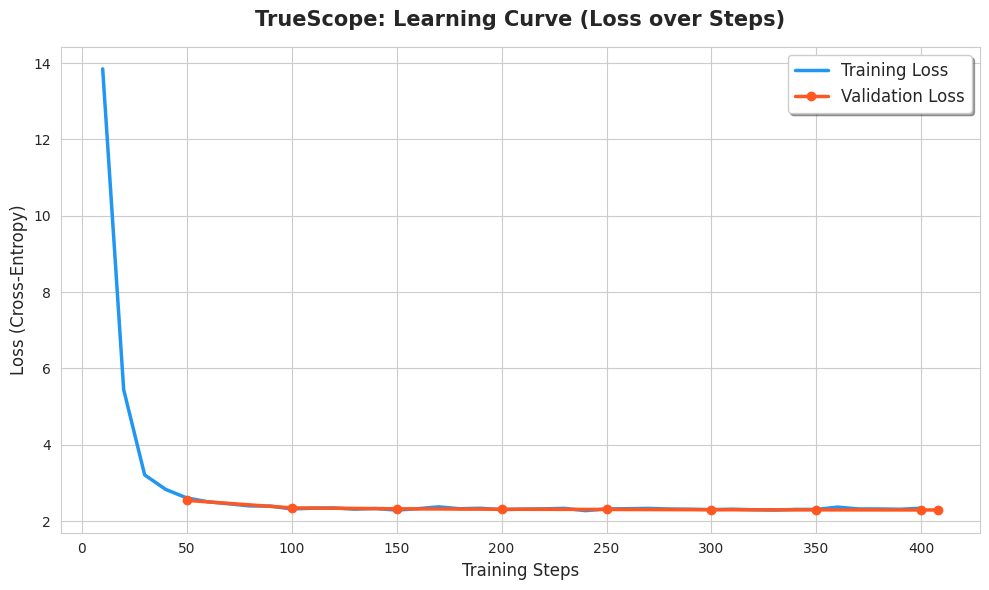

/tmp/ipykernel_133/2039497214.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracies, palette=['#4CAF50', '#FF9800'])


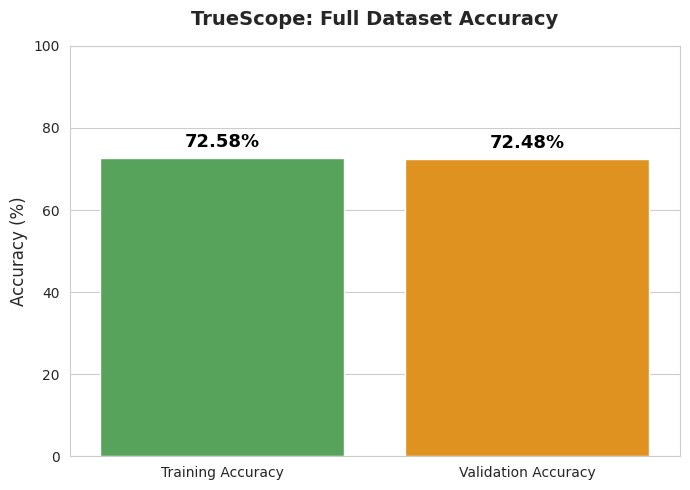

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


log_history = trainer.state.log_history

train_steps = [log["step"] for log in log_history if "loss" in log]
train_loss = [log["loss"] for log in log_history if "loss" in log]

val_steps = [log["step"] for log in log_history if "eval_loss" in log]
val_loss = [log["eval_loss"] for log in log_history if "eval_loss" in log]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plt.plot(train_steps, train_loss, label='Training Loss', color='#2196F3', linewidth=2.5)
if val_loss:
    plt.plot(val_steps, val_loss, label='Validation Loss', color='#FF5722', linewidth=2.5, marker='o', markersize=6)

plt.title('TrueScope: Learning Curve (Loss over Steps)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
plt.legend(loc="upper right", fontsize=12, frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('final_loss_curve.png', dpi=300)
plt.show()


labels = ['Training Accuracy', 'Validation Accuracy']
accuracies = [72.58, 72.48] 

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=labels, y=accuracies, palette=['#4CAF50', '#FF9800'])

plt.ylim(0, 100)
plt.title('TrueScope: Full Dataset Accuracy', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Accuracy (%)', fontsize=12)

# إضافة الأرقام فوق كل عمود
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=13, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.savefig('final_accuracy_bars.png', dpi=300)
plt.show()

Total Test Samples: 408


Test Set Progress:   0%|          | 0/408 [00:00<?, ?it/s]


FINAL TEST RESULTS
Overall Test Accuracy: 73.28%

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.78      0.70      0.74       220
    Real (1)       0.69      0.78      0.73       188

    accuracy                           0.73       408
   macro avg       0.74      0.74      0.73       408
weighted avg       0.74      0.73      0.73       408



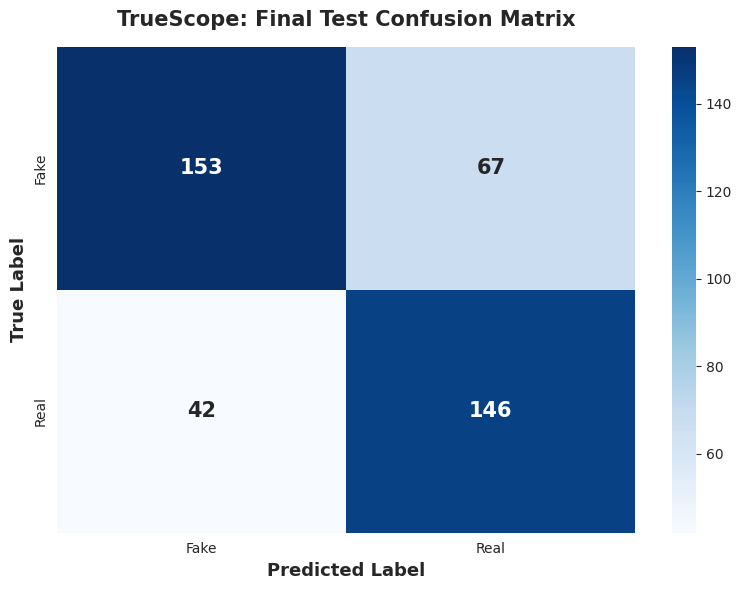

torch.autograd.grad_mode.set_grad_enabled(mode=True)

In [12]:
import torch
import gc
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

gc.collect()
torch.cuda.empty_cache()

model.eval()
torch.set_grad_enabled(False)

print(f"Total Test Samples: {len(test_subset)}")

true_labels = []
predicted_labels = []

for item in tqdm(test_subset, desc="Test Set Progress"):
    content = item['text']
    image_path = item['image_path']
    true_labels.append(item['label'])  
    
    try:
        from PIL import Image
        image = Image.open(image_path).convert("RGB")
        image.thumbnail((448, 448))
    except:
        image = Image.new('RGB', (224, 224), color='gray')
        
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": f"Is this news REAL or FAKE? Content: {content}\nAnswer:"}
            ]
        }
    ]
    
    prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    outputs = model.generate(**inputs, max_new_tokens=5, temperature=0.1)
    
    generated_text = processor.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip().upper()
    
    pred = 1 if "REAL" in generated_text else 0
    predicted_labels.append(pred)


print("\n" + "="*50)
print("FINAL TEST RESULTS")
print("="*50)

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Overall Test Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake (0)", "Real (1)"]))

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"],
            annot_kws={"size": 15, "weight": "bold"})

plt.title('TrueScope: Final Test Confusion Matrix', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig('final_test_confusion_matrix.png', dpi=300)
plt.show()

torch.set_grad_enabled(True)

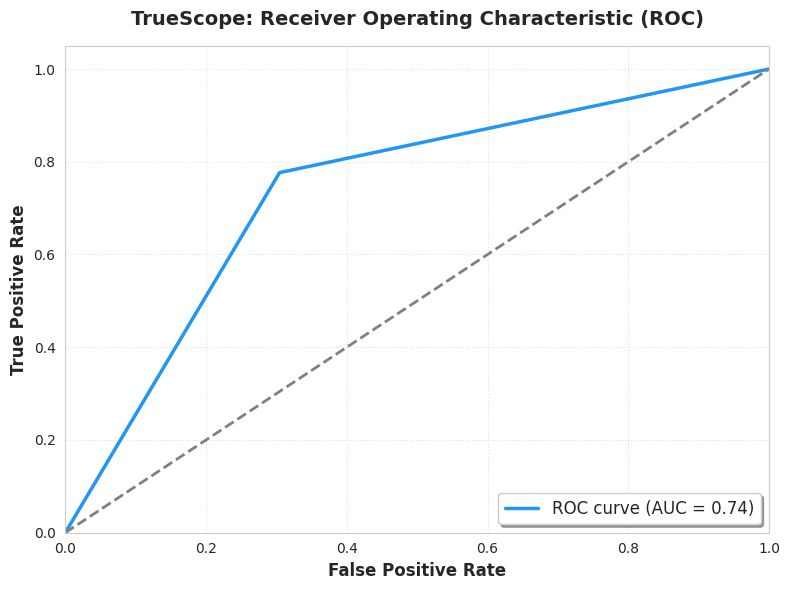

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--') 

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('TrueScope: Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('final_roc_curve.png', dpi=300)
plt.show()

/tmp/ipykernel_133/527316674.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['Fake News (0)', 'Real News (1)'], y=[fake_count, real_count], palette=['#E53935', '#4CAF50'])


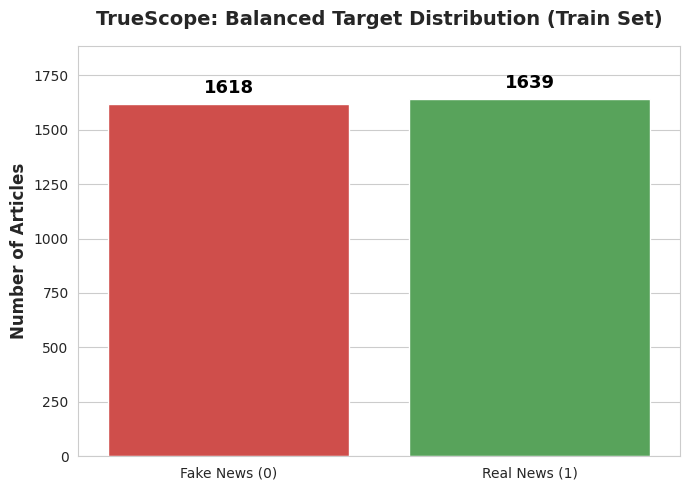

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


train_labels = [item['label'] for item in train_subset]
counts = Counter(train_labels)

fake_count = counts[0]
real_count = counts[1]

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=['Fake News (0)', 'Real News (1)'], y=[fake_count, real_count], palette=['#E53935', '#4CAF50'])

plt.title('TrueScope: Balanced Target Distribution (Train Set)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Articles', fontsize=12, fontweight='bold')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=13, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.ylim(0, max(fake_count, real_count) * 1.15)
plt.tight_layout()

plt.savefig('target_distribution.png', dpi=300)
plt.show()

🔍 Analyzing a random news article... Please wait.



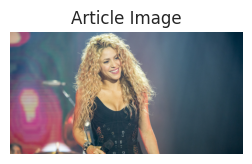

📰 NEWS CONTENT PREVIEW:
Shakira Postpones Her World Tour Due to Vocal Hemorrhage: 'My Nightmare Continues' Shakira has postponed her El Dorado World Tour until 2018 after suffering a hemorrhage on her right vocal cord. The Colombian singer, 40, made the announcement in a mo...
🎯 ACTUAL TRUTH: ---> REAL 🟢 <---
🤖 MODEL GUESS:  ---> REAL 🟢 <---

✅ MATCH! The model got it right! 🎉


In [16]:
import torch
import random
from PIL import Image
import matplotlib.pyplot as plt

# ==========================================
# 1. سحب عينة عشوائية من الـ Test Set
# ==========================================
sample = random.choice(test_subset)
image_path = sample['image_path']
news_content = sample['text']
actual_label = "REAL 🟢" if sample['label'] == 1 else "FAKE 🔴"

# ==========================================
# 2. الموديل بيفكر ويحلل...
# ==========================================
print(f"🔍 Analyzing a random news article... Please wait.\n")

try:
    image = Image.open(image_path).convert("RGB")
    # عرض الصورة عشان تشوفها بعينك
    plt.figure(figsize=(3,3))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Article Image")
    plt.show()
    
    image.thumbnail((448, 448))
except Exception as e:
    print(f"⚠️ Error loading image: {e}")
    image = Image.new('RGB', (224, 224), color='gray')

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": f"Is this news REAL or FAKE? Content: {news_content}\nAnswer:"}
        ]
    }
]

prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=prompt, images=image, return_tensors="pt")
inputs = {k: v.to(model.device) for k, v in inputs.items()}

model.eval()
with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=5, temperature=0.1)

generated_text = processor.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip().upper()

# ==========================================
# 3. طباعة النتيجة
# ==========================================
print("="*60)
print("📰 NEWS CONTENT PREVIEW:")
print(news_content[:250] + "..." if len(news_content) > 250 else news_content)
print("="*60)

print(f"🎯 ACTUAL TRUTH: ---> {actual_label} <---")

if "REAL" in generated_text:
    print(f"🤖 MODEL GUESS:  ---> REAL 🟢 <---")
elif "FAKE" in generated_text:
    print(f"🤖 MODEL GUESS:  ---> FAKE 🔴 <---")
else:
    print(f"⚪ Raw Output: {generated_text}")

if actual_label.split()[0] in generated_text:
    print("\n✅ MATCH! The model got it right! 🎉")
else:
    print("\n❌ MISMATCH! The model was fooled! 😅")
print("="*60)

🚀 Starting the Mismatch & Trick Tests...

🧪 TEST CASE: 1. Fake Text + Real Image


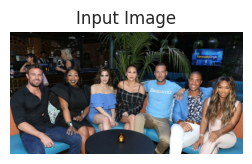

📝 INPUT TEXT:
Blake Shelton & Gwen Stefani ‘Stronger Than Ever’ After Miranda Lambert’s New Romance Blake Shelton & Gwen Stefani are bonding over the drama surrounding Miranda Lambert after she allegedly started dating her married tour mate. A source close to Gwen...

🤖 MODEL VERDICT: ---> FAKE 🔴 (The model caught the lie/mismatch!)



🧪 TEST CASE: 2. Real Text + Fake Image


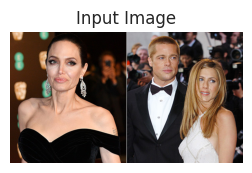

📝 INPUT TEXT:
Auli'i Cravalho Opens Up About The Possibility of Joining 'Dancing With The Stars' Performing at the Oscars and working on a new pilot are pretty exciting things, however, Auli’i Cravalho is more excited about going home.

“I’m really excited to be b...

🤖 MODEL VERDICT: ---> FAKE 🔴 (The model caught the lie/mismatch!)



🧪 TEST CASE: 3. Fake Text + Fake Image


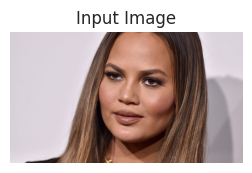

📝 INPUT TEXT:
Pregnant Kate Middleton vows to protect Meghan Markle from Camilla? Ever since the news broke that Prince Harry was dating Meghan Markle, the actress has been flooded with negative criticism. Things did not change, or rather took a disgusting turn, w...

🤖 MODEL VERDICT: ---> FAKE 🔴 (The model caught the lie/mismatch!)





In [24]:
import torch
import random
from PIL import Image
import matplotlib.pyplot as plt


real_samples = [item for item in test_subset if item['label'] == 1]
fake_samples = [item for item in test_subset if item['label'] == 0]

def run_trick_test(image_path, text_content, test_title):
    print("="*75)
    print(f"🧪 TEST CASE: {test_title}")
    print("="*75)
    
    try:
        image = Image.open(image_path).convert("RGB")
        plt.figure(figsize=(3,3))
        plt.imshow(image)
        plt.axis('off')
        plt.title("Input Image")
        plt.show()
        image.thumbnail((448, 448))
    except Exception as e:
        print(f"⚠️ Error loading image: {e}")
        image = Image.new('RGB', (224, 224), color='gray')

    print("📝 INPUT TEXT:")
    print(text_content[:250] + "...\n" if len(text_content) > 250 else text_content + "\n")

    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": f"Is this news REAL or FAKE? Content: {text_content}\nAnswer:"}
        ]}
    ]
    
    prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=5, temperature=0.1)

    generated_text = processor.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip().upper()

    if "REAL" in generated_text:
        print(f"🤖 MODEL VERDICT: ---> REAL 🟢 (The model believed it!)")
    elif "FAKE" in generated_text:
        print(f"🤖 MODEL VERDICT: ---> FAKE 🔴 (The model caught the lie/mismatch!)")
    else:
        print(f"⚪ Raw Output: {generated_text}")
    print("\n\n")



real_img = random.choice(real_samples)['image_path']
real_txt = random.choice(real_samples)['text']

fake_img = random.choice(fake_samples)['image_path']
fake_txt = random.choice(fake_samples)['text']

fake_img2 = random.choice(fake_samples)['image_path']
fake_txt2 = random.choice(fake_samples)['text']


print("🚀 Starting the Mismatch & Trick Tests...\n")

run_trick_test(real_img, fake_txt, "1. Fake Text + Real Image")

run_trick_test(fake_img, real_txt, "2. Real Text + Fake Image")

run_trick_test(fake_img2, fake_txt2, "3. Fake Text + Fake Image")